# Two-Step Multi-Scale Homogenization Workflow

This notebook demonstrates a **stochastic two-step (micro → meso)**
homogenization workflow managed by [pyiron](https://pyiron.org/).

The workflow logic (node definitions, KG queries, workflow assembly) lives in
`workflow_nodes.py` and is imported here.

In [1]:
import json
import pprint

import numpy as np
from scipy.stats import norm, qmc, spearmanr, rankdata
import matplotlib.pyplot as plt

from workflow_nodes import load_materials, build_workflow

## 1. Configuration

In [2]:
# Materials (IRIs will be resolved below)
FIBER_LABEL = "UNIE_640_E-Glass_Fiber"
MATRIX_LABEL = "Araldite_LY_556_Aradur_906_Accelerator_DY070"

# Micro-scale geometry
VOL_FRAC = 0.4
FIBER_RAD = 0.06
RVE_DEPTH_MICRO = 0.1
NUM_RAD = 5
NUM_DEPTH = 3
PLUGIN_PATH = (
    "/home/chri/w/OntOMat/Workflow/OntOMat_Workflow/"
    "Abaqus/Scripts/Abaqus_Plugin/MicroMechanics_v1.18/MicroMechanics"
)

# Meso-scale
ORIENTATIONS = [0, 30, -30, 60, -60, 90]

# Homogenized material IDs
MICRO_ID = "carbon_PA6_UD"
MESO_ID = "carbon_PA6_laminate"

# Abaqus
ABQ = "/isi/programs/simulia/2023/Commands/abaqus"
EVAL_SCRIPT_PATH = (
    "/home/chri/w/OntOMat/Workflow/OntOMat_Workflow/"
    "Abaqus/Scripts/extract_homogenized_stiffness.py"
)
REMOVE_FOLDER = False
SIM_BASE_PATH = "/isi/w/chri/OntOMat/Workflow/OntOMat_Workflow/Abaqus/Notebooks/"

# Stochastic sampling
N_SAMPLES = 30            # number of Latin Hypercube samples
N_STOCHASTIC_VARS = 4     # dimension of stochastic space

In [3]:
# Derived micro-RVE geometry
RVE_b_micro = np.sqrt(
    np.pi * FIBER_RAD**2 / (2 * VOL_FRAC * np.tan(np.radians(30)))
)
RVE_h_micro = RVE_b_micro * np.tan(np.radians(30))
RVE_VOLUME_MICRO = 4 * RVE_h_micro * RVE_b_micro * RVE_DEPTH_MICRO

print(f"RVE_b_micro = {RVE_b_micro:.4f}")
print(f"RVE_h_micro = {RVE_h_micro:.4f}")
print(f"RVE_VOLUME_MICRO = {RVE_VOLUME_MICRO:.4f}")

RVE_b_micro = 0.1565
RVE_h_micro = 0.0903
RVE_VOLUME_MICRO = 0.0057


## 2. Stochastic Sampling (Latin Hypercube)

In [4]:
# %% Stochastic Sampling
def generate_stochastic_shift(
    n: int, d: int, seed: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate a (n × d) Latin Hypercube design on discrete representative
    levels of the standard normal distribution.

    Each column is an independent permutation of the n bin centers,
    guaranteeing that every level appears exactly once per dimension.

    Parameters
    ----------
    n : int
        Number of samples (= number of equiprobable bins).
    d : int
        Number of stochastic variables.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    factors : np.ndarray, shape (n, d)
        Stochastic z-scores (discrete representative levels).
    centers : np.ndarray, shape (n,)
        Representative center of each bin (for visualization).
    borders : np.ndarray, shape (n-1,)
        Borders between adjacent bins (for visualization).
    """
    # Bin borders (includes -inf and +inf)
    borders_full = norm.ppf(np.linspace(0, 1, n + 1))

    # Conditional mean of each bin — finite for all bins including tails
    centers = np.array([
        n * (norm.pdf(borders_full[k]) - norm.pdf(borders_full[k + 1]))
        for k in range(n)
    ])

    # Interior borders only (for visualization)
    borders = borders_full[1:-1]

    # Latin Hypercube: one independent permutation of centers per dimension
    rng = np.random.default_rng(seed)
    shift = np.column_stack([rng.permutation(centers) for _ in range(d)])

    return shift, centers, borders

In [5]:
stochastic_shift, centers, borders = generate_stochastic_shift(
    N_SAMPLES, N_STOCHASTIC_VARS
)
print("Stochastic shift matrix:", stochastic_shift)


Stochastic shift matrix: [[ 2.22695995 -0.29683217 -0.12569851  0.3854506 ]
 [ 0.12569851 -0.90332939 -1.38574843 -2.22695995]
 [-0.67479939 -0.57319924 -1.03731908  1.19325918]
 [ 1.03731908 -1.65224158 -0.04180148  1.03731908]
 [ 0.90332939 -0.3854506   1.19325918 -0.90332939]
 [ 0.67479939  0.3854506  -0.29683217 -1.65224158]
 [-0.90332939  0.90332939 -1.19325918  0.90332939]
 [ 0.57319924 -0.78392218  1.03731908  0.47721481]
 [ 1.19325918  0.21049242  0.78392218 -0.21049242]
 [-0.3854506   0.67479939  0.04180148  1.38574843]
 [ 0.3854506  -1.38574843  1.65224158  0.12569851]
 [ 0.47721481 -2.22695995  0.90332939 -1.38574843]
 [-0.47721481  0.47721481  0.29683217 -0.3854506 ]
 [-0.78392218  1.19325918 -2.22695995 -1.19325918]
 [ 0.29683217 -0.67479939 -0.78392218 -0.29683217]
 [-1.19325918 -1.03731908  2.22695995 -0.12569851]
 [-2.22695995  0.29683217  0.47721481  0.21049242]
 [ 0.04180148  1.65224158  0.3854506  -0.67479939]
 [ 0.21049242  0.78392218 -1.65224158  0.29683217]
 [ 0.7

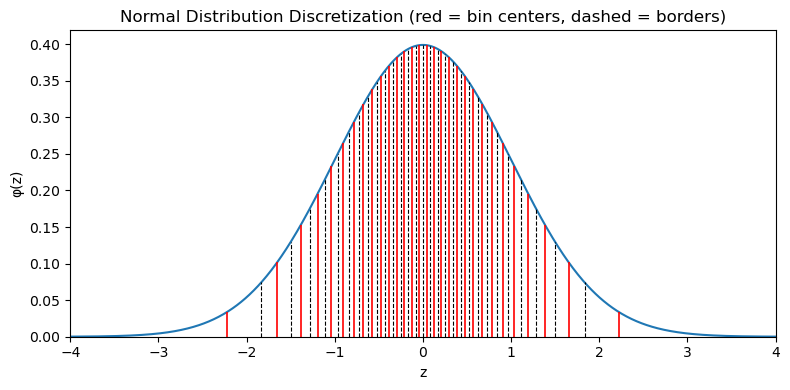

In [6]:
# Visualize the discretization of the normal distribution
x = np.linspace(-4, 4, 1000)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, norm.pdf(x), label="Standard Normal PDF")
for c in centers:
    ax.vlines(c, 0, norm.pdf(c), color="red", linewidth=1.2)
for b in borders:
    ax.vlines(b, 0, norm.pdf(b), color="black", linestyle="--", linewidth=0.8)
ax.set_xlim(-4, 4)
ax.set_ylim(bottom=0)
ax.set_title("Normal Distribution Discretization (red = bin centers, dashed = borders)")
ax.set_xlabel("z")
ax.set_ylabel("φ(z)")
plt.tight_layout()
plt.show()

## 3. Material Selection from Knowledge Graph

In [7]:
available_materials = load_materials()
print("Available materials:")
pprint.pp(available_materials)

Available materials:
{'UNIE_640_E-Glass_Fiber': 'https://www.materialdigital.de/ontomat/instance/UNIE_640_E-Glass_Fiber',
 'Accelerator DY 070': 'https://www.materialdigital.de/ontomat/instance/accelerator-DY-070',
 'UNIE-640': 'https://www.materialdigital.de/ontomat/instance/acrystal_L_4040_BB',
 'Aradur HY 906': 'https://www.materialdigital.de/ontomat/instance/aradur-HY-906',
 'Araldite_LY556_GFKUD_50': 'https://www.materialdigital.de/ontomat/instance/araldite_LY556_GFKUD_50',
 'Araldite LY 556': 'https://www.materialdigital.de/ontomat/instance/araldite_LY_556',
 'Araldite_LY_556_Aradur_906_Accelerator_DY070': 'https://www.materialdigital.de/ontomat/instance/araldite_LY_556_Aradur_906_Accelerator_DY070',
 'Generic carbon fiber': 'https://www.materialdigital.de/ontomat/instance/carbonFiber',
 'Siemens Epoxy GFK UD': 'https://www.materialdigital.de/ontomat/instance/epoxy-M_LY556_GFKUD0_01',
 'Generic glas fiber': 'https://www.materialdigital.de/ontomat/instance/glassFiber'}


In [8]:
fiber_material_IRI = available_materials[FIBER_LABEL]
matrix_material_IRI = available_materials[MATRIX_LABEL]

print(f"Fiber IRI:  {fiber_material_IRI}")
print(f"Matrix IRI: {matrix_material_IRI}")

Fiber IRI:  https://www.materialdigital.de/ontomat/instance/UNIE_640_E-Glass_Fiber
Matrix IRI: https://www.materialdigital.de/ontomat/instance/araldite_LY_556_Aradur_906_Accelerator_DY070


## 4. Build and Run the Workflow

In [9]:
wf = build_workflow()

In [13]:
sim_paths = []

for i in range(N_SAMPLES):
    sim_path = f"{SIM_BASE_PATH}sim_tmp_{i}/"
    sim_paths.append(sim_path)
    stochastic_factor_i = stochastic_shift[i, :].tolist()

    """
    wf(
        generate_sim_folder__sim_path=sim_path,
        ontomat_query__fiber_material_IRI=fiber_material_IRI,
        ontomat_query__matrix_material_IRI=matrix_material_IRI,
        ontomat_query__stochastic_factor=stochastic_factor_i,
        pre_process_micro__plugin_path=PLUGIN_PATH,
        pre_process_micro__abq=ABQ,
        pre_process_micro__vol_frac=VOL_FRAC,
        pre_process_micro__fiber_rad=FIBER_RAD,
        pre_process_micro__depth=RVE_DEPTH_MICRO,
        pre_process_micro__num_rad=NUM_RAD,
        pre_process_micro__num_depth=NUM_DEPTH,
        abaqus_evaluator_micro__abq=ABQ,
        abaqus_evaluator_micro__eval_script_path=EVAL_SCRIPT_PATH,
        abaqus_evaluator_micro__RVE_volume=RVE_VOLUME_MICRO,
        ontomat_upload_micro__material_ID=MICRO_ID,
        pre_process_meso__orientations=ORIENTATIONS,
        pre_process_meso__plugin_path=PLUGIN_PATH,
        pre_process_meso__abq=ABQ,
        abaqus_evaluator_meso__abq=ABQ,
        abaqus_evaluator_meso__eval_script_path=EVAL_SCRIPT_PATH,
        ontomat_upload_meso__material_ID=MESO_ID,
        remove_sim_folder__remove=REMOVE_FOLDER,
    )
    """

    print(f"Sample {i} complete.\n")

Sample 0 complete.

Sample 1 complete.

Sample 2 complete.

Sample 3 complete.

Sample 4 complete.

Sample 5 complete.

Sample 6 complete.

Sample 7 complete.

Sample 8 complete.

Sample 9 complete.

Sample 10 complete.

Sample 11 complete.

Sample 12 complete.

Sample 13 complete.

Sample 14 complete.

Sample 15 complete.

Sample 16 complete.

Sample 17 complete.

Sample 18 complete.

Sample 19 complete.

Sample 20 complete.

Sample 21 complete.

Sample 22 complete.

Sample 23 complete.

Sample 24 complete.

Sample 25 complete.

Sample 26 complete.

Sample 27 complete.

Sample 28 complete.

Sample 29 complete.



## 5. Stochastic Post-Processing

In [14]:
def compute_prcc(X, y):
    """
    Compute Partial Rank Correlation Coefficients (PRCC).
    
    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_inputs)
        Input sample matrix (e.g., stochastic_shift).
    y : np.ndarray, shape (n_samples,)
        Output vector (e.g., E1 values).
    
    Returns
    -------
    prcc_values : np.ndarray, shape (n_inputs,)
        PRCC for each input parameter.
    p_values : np.ndarray, shape (n_inputs,)
        Two-sided p-values for statistical significance.
    """
    n, d = X.shape
    
    # Rank-transform all variables
    X_ranked = np.apply_along_axis(rankdata, 0, X)
    y_ranked = rankdata(y)
    
    prcc_values = np.zeros(d)
    p_values = np.zeros(d)
    
    for i in range(d):
        # Regress X_i (ranked) on all other X_j (ranked)
        others = np.delete(X_ranked, i, axis=1)
        # Add intercept
        others_aug = np.column_stack([np.ones(n), others])
        
        # Residuals of X_i ~ other inputs
        beta_x = np.linalg.lstsq(others_aug, X_ranked[:, i], rcond=None)[0]
        resid_x = X_ranked[:, i] - others_aug @ beta_x
        
        # Residuals of Y ~ other inputs
        beta_y = np.linalg.lstsq(others_aug, y_ranked, rcond=None)[0]
        resid_y = y_ranked - others_aug @ beta_y
        
        # Correlation of residuals = PRCC
        corr, pval = spearmanr(resid_x, resid_y)
        prcc_values[i] = corr
        p_values[i] = pval
    
    return prcc_values, p_values


def plot_tornado(prcc_dict, output_label, input_labels, ax=None):
    """
    Tornado plot (horizontal bar chart) for PRCC values.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    
    values = np.array([prcc_dict[lbl] for lbl in input_labels])
    colors = ['#d62728' if v < 0 else '#1f77b4' for v in values]
    
    # Sort by absolute value
    sort_idx = np.argsort(np.abs(values))
    sorted_labels = [input_labels[i] for i in sort_idx]
    sorted_values = values[sort_idx]
    sorted_colors = [colors[i] for i in sort_idx]
    
    ax.barh(range(len(sorted_values)), sorted_values, color=sorted_colors, 
            edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(sorted_labels)))
    ax.set_yticklabels(sorted_labels)
    ax.set_xlabel('PRCC')
    ax.set_title(f'Sensitivity of {output_label}')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    return ax

In [15]:
engineering_constants_keys = [
    "E1", "E2", "E3", "G12", "G13", "G23", "nu12", "nu13", "nu23"
]

micro_engineering_constants = {key: {"values": []} for key in engineering_constants_keys}
meso_engineering_constants = {key: {"values": []} for key in engineering_constants_keys}

micro_engineering_constants["E1"]["label"] = r'$E_1$'
micro_engineering_constants["E2"]["label"] = r'$E_2$'
micro_engineering_constants["E3"]["label"] = r'$E_3$'
micro_engineering_constants["G12"]["label"] = r'$G_{12}$'
micro_engineering_constants["G13"]["label"] = r'$G_{13}$'
micro_engineering_constants["G23"]["label"] = r'$G_{23}$'
micro_engineering_constants["nu12"]["label"] = r'$\nu_{12}$'
micro_engineering_constants["nu13"]["label"] = r'$\nu_{13}$'
micro_engineering_constants["nu23"]["label"] = r'$\nu_{23}$'

meso_engineering_constants["E1"]["label"] = r'$E_1$'
meso_engineering_constants["E2"]["label"] = r'$E_2$'
meso_engineering_constants["E3"]["label"] = r'$E_3$'
meso_engineering_constants["G12"]["label"] = r'$G_{12}$'
meso_engineering_constants["G13"]["label"] = r'$G_{13}$'
meso_engineering_constants["G23"]["label"] = r'$G_{23}$'
meso_engineering_constants["nu12"]["label"] = r'$\nu_{12}$'
meso_engineering_constants["nu13"]["label"] = r'$\nu_{13}$'
meso_engineering_constants["nu23"]["label"] = r'$\nu_{23}$'

for sim_path in sim_paths:
    with open(sim_path + "UD_hex_homogen_engineering_constants.json", "r") as f:
        ec_micro = json.load(f)
        for key in engineering_constants_keys:
            micro_engineering_constants[key]["values"].append(ec_micro[key])

    with open(sim_path + "UD_laminate_homogen_engineering_constants.json", "r") as f:
        ec_meso = json.load(f)
        for key in engineering_constants_keys:
            meso_engineering_constants[key]["values"].append(ec_meso[key])

# Compute statistics
for key in engineering_constants_keys:
    micro_engineering_constants[key]["mean"] = float(
        np.mean(micro_engineering_constants[key]["values"])
    )
    micro_engineering_constants[key]["std"] = float(
        np.std(micro_engineering_constants[key]["values"])
    )

    meso_engineering_constants[key]["mean"] = float(
        np.mean(meso_engineering_constants[key]["values"])
    )
    meso_engineering_constants[key]["std"] = float(
        np.std(meso_engineering_constants[key]["values"])
    )

In [16]:
# Persist results
with open("micro_engineering_constants.json", "w") as f:
    json.dump(micro_engineering_constants, f, indent=2, sort_keys=True)

with open("meso_engineering_constants.json", "w") as f:
    json.dump(meso_engineering_constants, f, indent=2, sort_keys=True)

print("Results written to micro_engineering_constants.json and meso_engineering_constants.json")

Results written to micro_engineering_constants.json and meso_engineering_constants.json


In [17]:
# Quick summary
print("=== Micro-scale (mean ± std) ===")
for key in engineering_constants_keys:
    m = micro_engineering_constants[key]["mean"]
    s = micro_engineering_constants[key]["std"]
    print(f"  {key:>4s}: {m:.4f} ± {s:.4f}")

print("\n=== Meso-scale (mean ± std) ===")
for key in engineering_constants_keys:
    m = meso_engineering_constants[key]["mean"]
    s = meso_engineering_constants[key]["std"]
    print(f"  {key:>4s}: {m:.4f} ± {s:.4f}")

=== Micro-scale (mean ± std) ===
    E1: 30962.8608 ± 1408.2233
    E2: 6785.8604 ± 350.4420
    E3: 6785.8369 ± 350.4408
   G12: 2197.8120 ± 100.0395
   G13: 2308.4784 ± 109.8798
   G23: 2308.4824 ± 109.8800
  nu12: 0.2984 ± 0.0134
  nu13: 0.2984 ± 0.0134
  nu23: 0.5439 ± 0.0443

=== Meso-scale (mean ± std) ===
    E1: 14424.6287 ± 485.2330
    E2: 14424.6288 ± 485.2331
    E3: 8193.9464 ± 574.3873
   G12: 2251.6800 ± 103.7204
   G13: 2251.6800 ± 103.7204
   G23: 5450.3543 ± 182.1057
  nu12: 0.3233 ± 0.0078
  nu13: 0.3534 ± 0.0242
  nu23: 0.3534 ± 0.0242


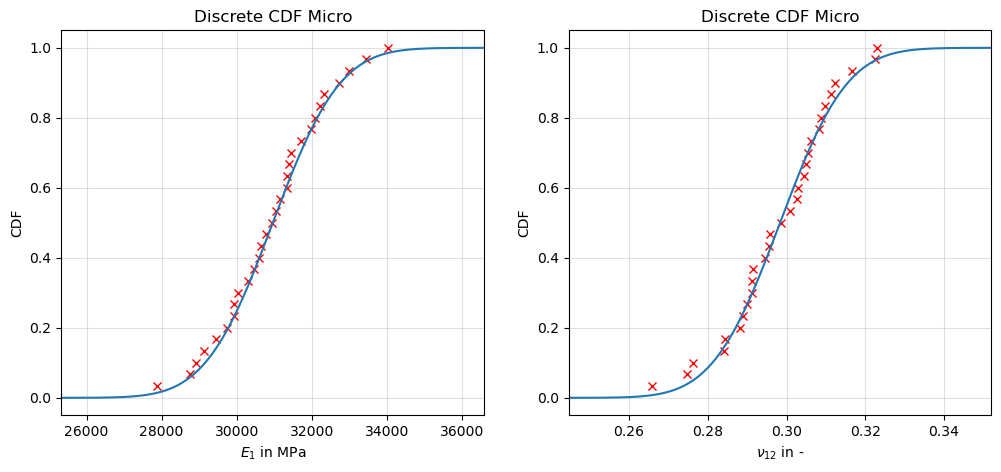

In [23]:
# Visualize the CDF for some engineering constants
from scipy.stats import norm

CDF_fit = lambda x, mu, sigma: norm(mu, sigma).cdf(x)

E1_micro = np.sort(micro_engineering_constants['E1']['values'])
E1_micro_mean = micro_engineering_constants['E1']['mean']
E1_micro_std = micro_engineering_constants['E1']['std']
CFD_E1_micro = np.arange(1, len(E1_micro)+1) / len(E1_micro)
x_E1 = np.linspace(E1_micro_mean - 4*E1_micro_std, E1_micro_mean + 4*E1_micro_std, 1000)

nu12_micro = np.sort(micro_engineering_constants['nu12']['values'])
nu12_micro_mean = micro_engineering_constants['nu12']['mean']
nu12_micro_std = micro_engineering_constants['nu12']['std']
CFD_nu12_micro = np.arange(1, len(nu12_micro)+1) / len(nu12_micro)
x_nu12 = np.linspace(nu12_micro_mean - 4*nu12_micro_std, nu12_micro_mean + 4*nu12_micro_std, 1000)


fig, axes = plt.subplots(1,2, figsize=(12, 5))

axes[0].plot(E1_micro, CFD_E1_micro, 'x', color='red')
axes[0].plot(x_E1, CDF_fit(x_E1, E1_micro_mean, E1_micro_std))
axes[0].set_xlabel('$E_1$ in MPa')         
axes[0].set_ylabel('CDF')                  
axes[0].set_title('Discrete CDF Micro')       
axes[0].grid(alpha=0.4)
axes[0].set_xlim(E1_micro_mean - 4*E1_micro_std, E1_micro_mean + 4*E1_micro_std)

axes[1].plot(nu12_micro, CFD_nu12_micro, 'x', color='red')
axes[1].plot(x_nu12, CDF_fit(x_nu12, nu12_micro_mean, nu12_micro_std))
axes[1].set_xlabel(r'$\nu_{12}$ in -')         
axes[1].set_ylabel('CDF')                  
axes[1].set_title('Discrete CDF Micro')       
axes[1].grid(alpha=0.4)
axes[1].set_xlim(nu12_micro_mean - 4*nu12_micro_std, nu12_micro_mean + 4*nu12_micro_std)

plt.show() 


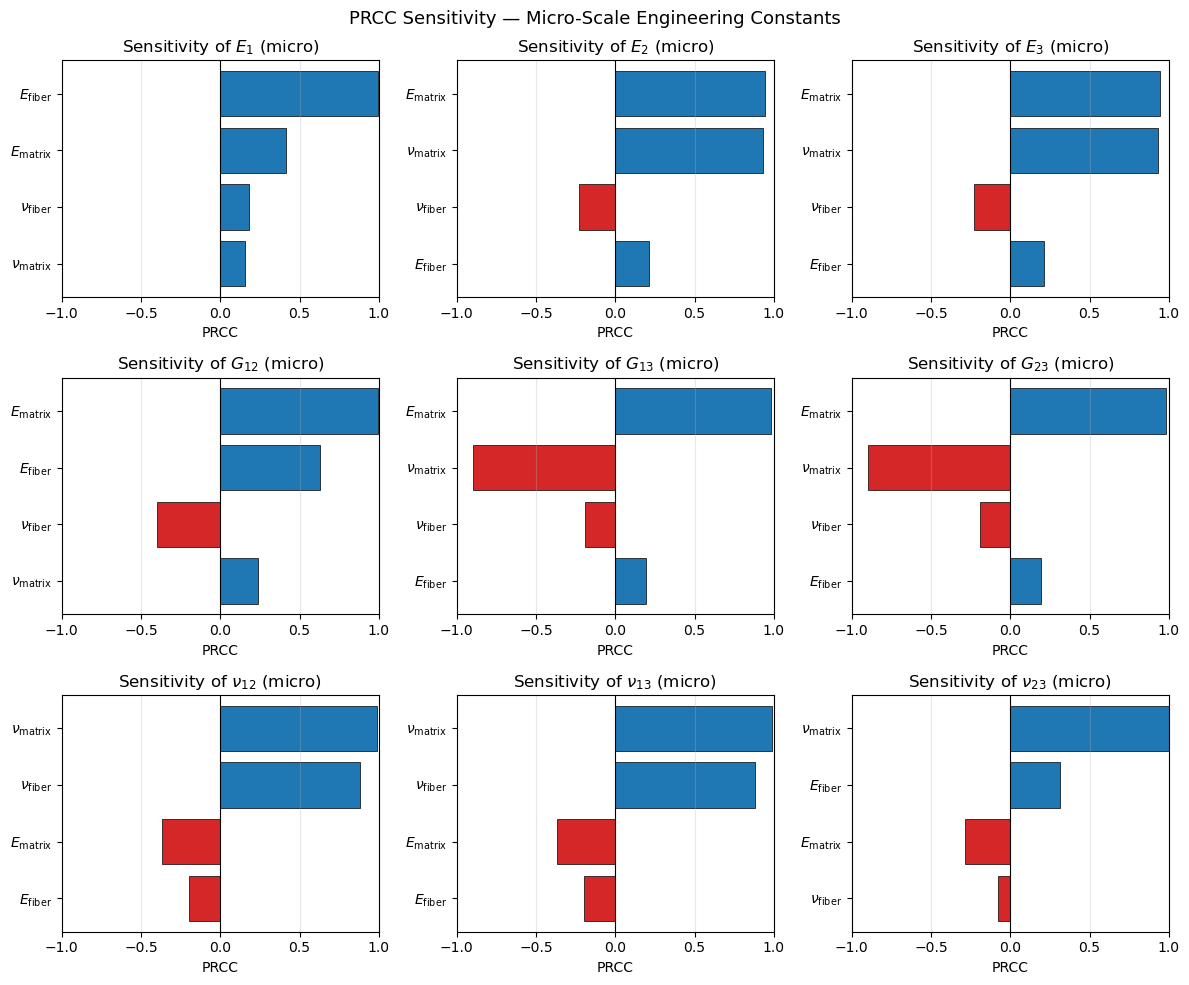

In [82]:
X = stochastic_shift  # z-scores from your LHS

input_labels = [r'$E_\mathrm{fiber}$', r'$E_\mathrm{matrix}$', 
                r'$\nu_\mathrm{fiber}$', r'$\nu_\mathrm{matrix}$']

# --- Micro-scale sensitivity ---
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for idx, key in enumerate(engineering_constants_keys):
    y = np.array(micro_engineering_constants[key]['values'])
    prcc_vals, p_vals = compute_prcc(X, y)
    
    prcc_dict = {lbl: prcc_vals[i] for i, lbl in enumerate(input_labels)}
    plot_tornado(prcc_dict, f'{micro_engineering_constants[key]['label']} (micro)', input_labels, ax=axes[idx])

plt.suptitle('PRCC Sensitivity — Micro-Scale Engineering Constants', fontsize=13)
plt.tight_layout()
plt.savefig('sensitivity_micro_prcc.pdf', bbox_inches='tight')
plt.show()



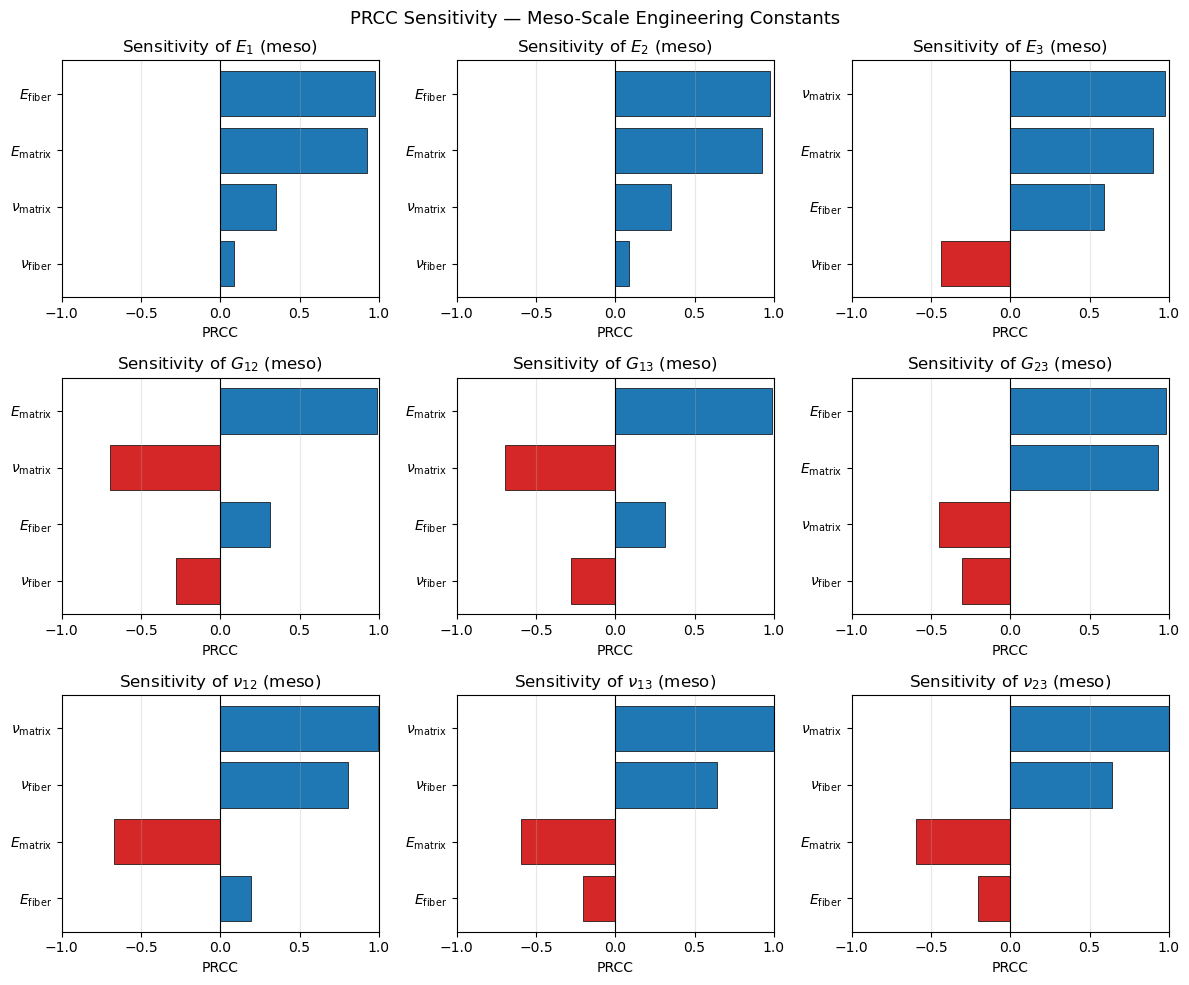

In [83]:
# --- Meso-scale sensitivity ---
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for idx, key in enumerate(engineering_constants_keys):
    y = np.array(meso_engineering_constants[key]['values'])
    prcc_vals, p_vals = compute_prcc(X, y)
    
    prcc_dict = {lbl: prcc_vals[i] for i, lbl in enumerate(input_labels)}
    plot_tornado(prcc_dict, f'{meso_engineering_constants[key]['label']} (meso)', input_labels, ax=axes[idx])

plt.suptitle('PRCC Sensitivity — Meso-Scale Engineering Constants', fontsize=13)
plt.tight_layout()
plt.savefig('sensitivity_meso_prcc.pdf', bbox_inches='tight')
plt.show()

## 6. Workflow Graph

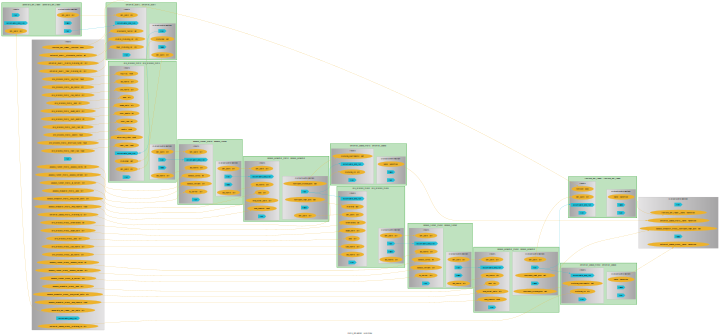

In [87]:
wf.draw(size=(10, 10))